# Sheet 04 — Dimensionality Reduction & Autoencoders

Introduction to Deep Learning — Summer Semester 2026

Ulf Krumnack & Robin Rawiel — Universität OsnabrückDue: May 17, 2026

In this exercise sheet you will connect the main ideas of the chapter:
dimensionality reduction, PCA as a linear baseline, fully connected and
convolutional autoencoders, denoising, anomaly detection, and
U-Net-inspired segmentation concepts. A short bonus part at the end
revisits sparse autoencoders.

## Task 1: Theory Questions \[6 points\]

### 1.1 Geometry and Linear Compression \[2 points\]

1.  Explain the curse of dimensionality in your own words. Why does the
    manifold hypothesis make dimensionality reduction plausible for real
    data such as images?

2.  Let $x \in \mathbb{R}^D$ be centered data and let
    $w \in \mathbb{R}^D$ be a unit vector. Show that the reconstruction
    error after projection onto the one-dimensional subspace spanned by
    $w$ is
    $$\|x - ww^\top x\|^2 = \|x\|^2 - (w^\top x)^2.$$
    Why does minimizing the average reconstruction error correspond to
    maximizing the variance of the projected data?

3.  In what sense is a linear autoencoder related to PCA? What
    additional expressive power do non-linear autoencoders provide?

### 1.2 Autoencoders and Regularization \[2 points\]

1.  Describe the encoder, bottleneck, and decoder of an autoencoder.
    What objective is used for training?

2.  Why can an autoencoder with a very wide bottleneck or excessive
    model capacity overfit even though the target is just the input
    itself?

3.  Compare a denoising autoencoder and a sparse autoencoder. What
    additional constraint does each introduce, and what kind of
    representation does it encourage?

### 1.3 Applications and Architectures \[2 points\]

1.  Explain how reconstruction error can be used for anomaly detection.

2.  Why are convolutional autoencoders usually preferable to fully
    connected autoencoders for image data?

3.  What does a U-Net add to the basic encoder-decoder idea, and why are
    skip connections helpful for image segmentation? Which metric is
    often preferred over plain accuracy for segmentation, and why?

## Task 2: PCA and Autoencoder Variants on MNIST \[10 points\]

**Learning objectives:**

- Compare PCA, linear autoencoders, and non-linear autoencoders
- Explore convolutional and optionally sparse autoencoder variants
- Measure reconstruction quality under different bottleneck sizes
- Visualize low-dimensional latent representations

Tip: get the PCA baseline working first and reuse the same
reconstruction-error and visualization code for the autoencoder
variants. That gives you a simple reference point for checking whether
each new model is actually improving the reconstructions.

### 2.1 Setup \[1 point\]

To keep runtimes manageable on student laptops, we work with subsets of
MNIST rather than the full dataset.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()
full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
full_test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

# Use smaller subsets so every model can be trained in a reasonable amount of time.
train_subset = Subset(full_train_dataset, range(8000))
test_subset = Subset(full_test_dataset, range(1000))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=256, shuffle=False)


def subset_to_matrix(subset):
    images = []
    labels = []
    for image, label in subset:
        images.append(image.view(-1).numpy())
        labels.append(label)
    return np.stack(images), np.array(labels)


def mean_reconstruction_error(x, x_hat):
    return float(np.mean((x - x_hat) ** 2))


def batch_reconstruction_error(x, x_hat):
    """Return one reconstruction-error value per sample."""
    return ((x_hat - x) ** 2).view(x.size(0), -1).mean(dim=1)


X_train, y_train = subset_to_matrix(train_subset)
X_test, y_test = subset_to_matrix(test_subset)

print("Train matrix:", X_train.shape)
print("Test matrix:", X_test.shape)
print("Device:", device)

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.83MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 255kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.65MB/s]


Train matrix: (8000, 784)
Test matrix: (1000, 784)
Device: cpu


### 2.2 PCA Baseline \[1 point\]

Fit PCA with latent dimensions $d \in \{2, 16, 64\}$. Compare the
test-set reconstruction error and visualize the reconstructions of the
first eight test images.

Hint: you do not have to implement PCA yourself. The main point of this
task is to use `fit`, `transform`, and `inverse_transform` as a linear
baseline for the autoencoders.

PCA d=2: test MSE = 0.054905


/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zer

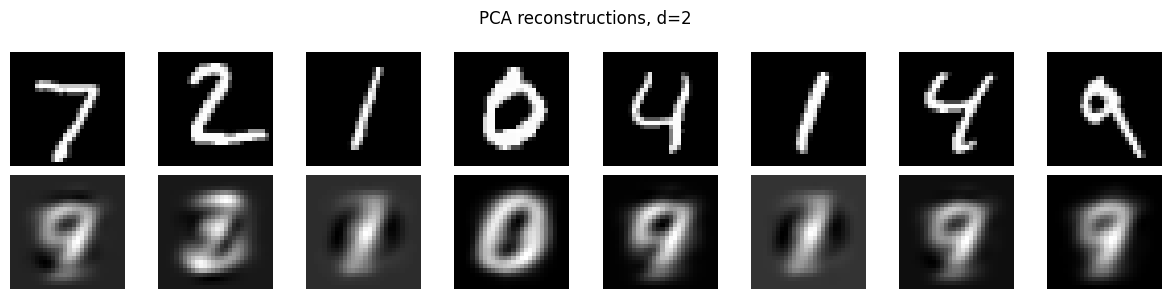

/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zer

PCA d=16: test MSE = 0.027500


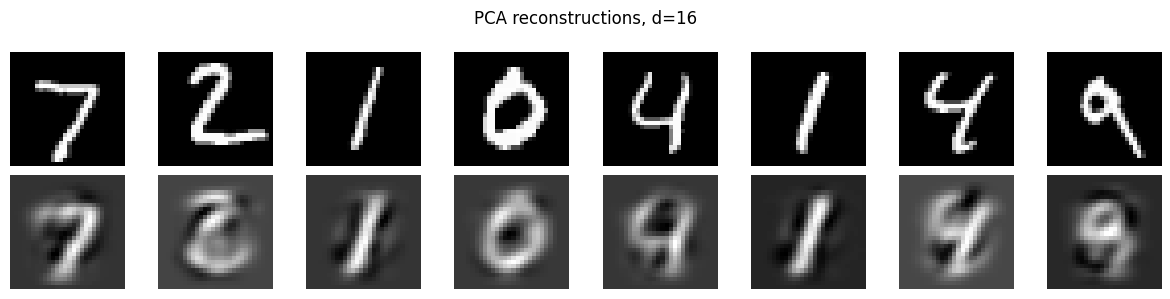

PCA d=64: test MSE = 0.009449


/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_pca.py:604: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/alexpometun/Desktop/Workspace/01_University/Masters/03_Semestr/Introduction to Deep Learning/evolution-of-ml-models/dlvenv/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zer

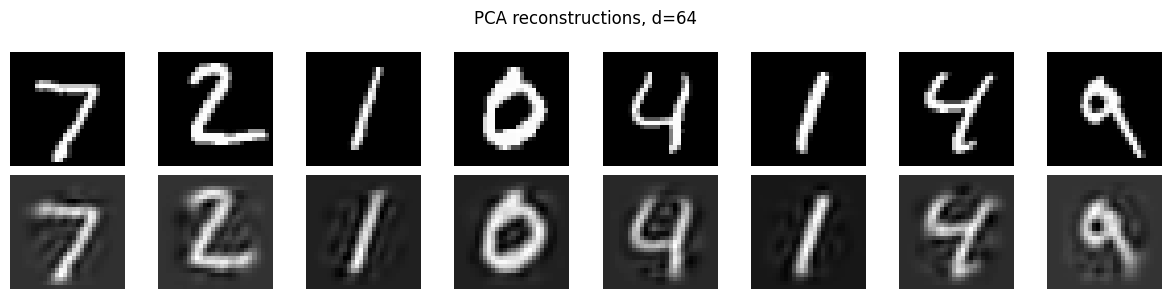

In [7]:
# TODO: Your solution here
for n_components in [2,16,64]:
    pca = PCA(n_components=n_components)
    pca.fit(X_train)

    Z = pca.transform(X_test)
    X_recon = pca.inverse_transform(Z)

    err = mean_reconstruction_error(X_test, X_recon)
    print(f"PCA d={n_components}: test MSE = {err:.6f}")

    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i in range(8):
        axes[0, i].imshow(X_test[i].reshape(28, 28), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(X_recon[i].reshape(28, 28), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("orig")
    axes[1, 0].set_ylabel("recon")
    plt.suptitle(f"PCA reconstructions, d={n_components}")
    plt.tight_layout()
    plt.show()



### 2.3 Linear Autoencoder \[2 points\]

Implement and train a linear autoencoder with latent dimension $d = 16$.
Compare its test reconstruction error and its reconstructions with the
PCA baseline of the same dimension.

Hint: this is the neural-network version of the PCA setup above. The
encoder compresses, the decoder reconstructs, and there are no hidden
non-linearities in between.

In [10]:
class LinearAutoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Linear(784, 16)
        self.decoder = nn.Linear(16, 784)

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

    def encode(self, x):
        z = self.encoder(x)
        return z


def train_autoencoder(model, loader, epochs=10, lr=1e-3, noise_fn=None):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    criteria = nn.MSELoss()

    for epoch in range(epochs):
        for batch, _ in loader:
            batch = batch.view(batch.size(0), -1)
            x_hat = model(batch)
            
            loss = criteria(x_hat, batch)
            history.append(loss.item())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    return history


def evaluate_autoencoder(model, loader):
    model.eval()
    criteria = nn.MSELoss()
    total_loss = 0
    
    with torch.no_grad():
        for batch, _ in loader:
            batch = batch.view(batch.size(0), -1)
            x_hat = model(batch)
            loss = criteria(x_hat, batch)
            total_loss += loss.item()
    return total_loss / len(loader)

Linear AE d=16: test MSE = 0.035339


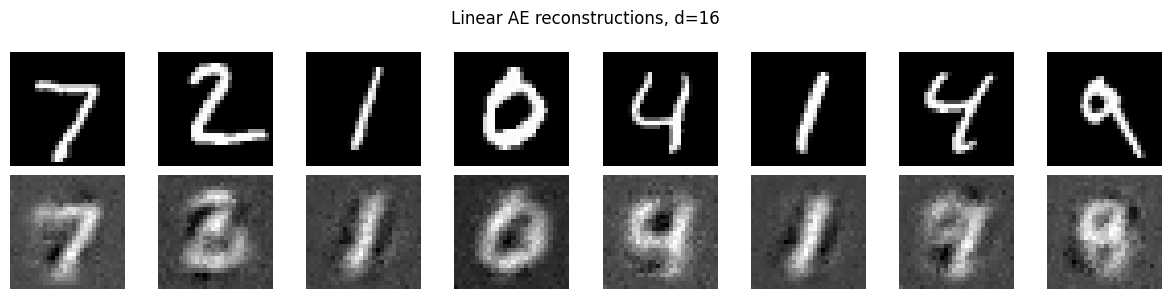

In [16]:
model = LinearAutoencoder(latent_dim=16)
history = train_autoencoder(model, train_loader)
test_mse = evaluate_autoencoder(model, test_loader)
print(f"Linear AE d=16: test MSE = {test_mse:.6f}")

# visualize first 8 reconstructions
model.eval()
with torch.no_grad():
    imgs = torch.tensor(X_test[:8]).float().to(device)        # X_test are flattened numpy vectors
    recon = model(imgs).cpu().numpy()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(X_test[i].reshape(28, 28), cmap="gray"); axes[0, i].axis("off")
    axes[1, i].imshow(recon[i].reshape(28, 28), cmap="gray"); axes[1, i].axis("off")
axes[0, 0].set_ylabel("orig"); axes[1, 0].set_ylabel("recon")
plt.suptitle("Linear AE reconstructions, d=16")
plt.tight_layout()
plt.show()

### 2.4 Non-linear Autoencoder and Latent Space \[3 points\]

Implement a non-linear autoencoder with a two-dimensional bottleneck.
Train it and visualize the latent codes of the test set. Compare the
resulting 2D representation with the 2D PCA projection.

Hint: you can reuse `train_autoencoder` and `evaluate_autoencoder`
without any changes. The only difference to the linear autoencoder is
the deeper encoder and decoder with ReLU activations.

In [17]:
class NonlinearAutoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

    def encode(self, x):
        z = self.encoder(x)
        return z

def collect_latent_codes(model, loader):
    model.eval()
    all_codes = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.view(images.size(0), -1)
            z = model.encode(images)
            all_codes.append(z)
            all_labels.append(labels)
    
    return torch.cat(all_codes).numpy(), torch.cat(all_labels).numpy()

Nonlinear AE d=2: test MSE = 0.045291


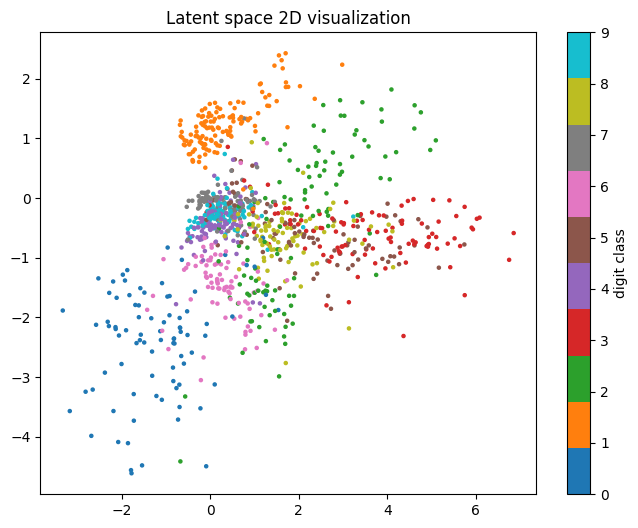

In [18]:
# TODO: Your solution here
model = NonlinearAutoencoder(latent_dim=2)
history = train_autoencoder(model, train_loader)
test_mse = evaluate_autoencoder(model, test_loader)
print(f"Nonlinear AE d=2: test MSE = {test_mse:.6f}")

codes, labels = collect_latent_codes(model, test_loader)
plt.figure(figsize=(8, 6))
plt.scatter(codes[:, 0], codes[:, 1], c=labels, cmap='tab10', s=5)
plt.colorbar(label='digit class')
plt.title('Latent space 2D visualization')
plt.show()


### 2.5 Convolutional Autoencoder \[3 points\]

Implement a convolutional autoencoder with transposed convolutions in
the decoder. Train it on MNIST and compare its reconstruction quality
with the fully connected autoencoders above.

Hint: keep track of the spatial sizes. With stride $2$ convolutions, the
encoder reduces $28 \times 28 \to 14 \times 14 \to 7 \times 7$, so the
decoder must reverse exactly that path. The `output_padding=1` terms
help recover the original image size.

In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_channels=8):
        super().__init__()
        # Shape path: 28x28 -> 14x14 -> 7x7 -> 14x14 -> 28x28.
        # TODO: Your solution here

    def forward(self, x):
        # TODO: Your solution here

In [ ]:
# TODO: Your solution here

### 2.6 Sparse Autoencoder (Bonus) \[2 points\]

This bonus task asks you to add an $L1$ penalty to the latent code so
that the model learns sparse activations.

Hint: this part reuses almost everything from the fully connected
autoencoder above. Start from the previous training loop, let the model
return the latent code $z$, and add a sparsity term such as
$\lambda \lVert z \rVert_1$ to the reconstruction loss before
backpropagation.

In [ ]:
class SparseAutoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        """MLP autoencoder that also returns the latent code z."""
        super().__init__()
        # TODO: Your solution here

    def encode(self, x):
        # TODO: Your solution here

    def forward(self, x):
        # TODO: Your solution here


def train_sparse_autoencoder(model, loader, epochs=10, lr=1e-3, lambda_sparse=1e-3):
    """Train with reconstruction loss plus a sparsity penalty on z."""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    recon_history = []
    sparse_history = []

    for epoch in range(epochs):
        # TODO: Your solution here

    return recon_history, sparse_history


def evaluate_sparse_autoencoder(model, loader):
    # TODO: Your solution here

In [ ]:
# TODO: Your solution here

## Task 3: Denoising and Anomaly Detection \[4 points\]

**Learning objectives:**

- Train a convolutional denoising autoencoder
- Use reconstruction error as an anomaly score
- Relate encoder-decoder ideas to downstream applications

Hint: first check that the digit filtering works and visualize a few
noisy inputs together with their reconstructions. For this task, the
important part is to see that normal digits tend to have lower
reconstruction error than anomaly digits; extensive hyperparameter
tuning is not necessary.

### 3.1 One-Class Denoising Autoencoder \[2 points\]

Train a convolutional denoising autoencoder on only one digit class, for
example digit `1`. Later we will use digit `7` as an anomaly class.

Hint: the class labels are already fixed for you below, so you only need
to filter the dataset and run the model on the reduced subsets.

In [ ]:
normal_digit = 1
anomaly_digit = 7


def filter_digits(dataset, allowed_digits, max_samples=None):
    indices = [index for index, (_, label) in enumerate(dataset) if label in allowed_digits]
    if max_samples is not None:
        indices = indices[:max_samples]
    return Subset(dataset, indices)


# Keep the one-class experiment compact so it finishes quickly.
normal_train_subset = filter_digits(full_train_dataset, [normal_digit], max_samples=4000)
normal_test_subset = filter_digits(full_test_dataset, [normal_digit], max_samples=500)
anomaly_test_subset = filter_digits(full_test_dataset, [anomaly_digit], max_samples=500)

normal_train_loader = DataLoader(normal_train_subset, batch_size=128, shuffle=True)
normal_test_loader = DataLoader(normal_test_subset, batch_size=256, shuffle=False)
anomaly_test_loader = DataLoader(anomaly_test_subset, batch_size=256, shuffle=False)

print("Normal train samples:", len(normal_train_subset))
print("Normal test samples:", len(normal_test_subset))
print("Anomaly test samples:", len(anomaly_test_subset))

In [ ]:
class ConvDenoisingAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Your solution here

    def forward(self, x):
        # TODO: Your solution here


def add_noise(images, noise_factor=0.35):
    # TODO: Your solution here

### 3.2 Training and Denoising \[1 point\]

Train the model on noisy versions of the normal digit and reconstruct
the clean target.

Hint: this is the same training pattern as before. The only difference
is that the input is noisy while the target stays clean.

In [ ]:
# TODO: Your solution here

### 3.3 Anomaly Detection with Reconstruction Error \[1 point\]

Evaluate the trained model on normal digits and anomalous digits. Plot
both reconstruction-error distributions, choose a threshold, and
interpret the result.

Hint: you do not need to search for the perfect threshold. Using the
$95\%$ quantile of the normal errors is already a reasonable simple
choice.

In [ ]:
def reconstruction_errors(model, loader):
    # TODO: Your solution here

In [ ]:
# TODO: Your solution here

1.  Why is reconstruction error a sensible anomaly score in this setup?

2.  Would adding U-Net-style skip connections necessarily improve
    anomaly detection? Briefly justify your answer.